# Simulación progresiva de un circuito neuromotor mediante neuronas de Izhikevich

## Objetivo general

El proyecto avanza desde una neurona individual hasta un circuito simplificado de motoneuronas y células de Renshaw. Su propósito es explorar cómo input, heterogeneidad y conectividad modifican la actividad spiking, y cómo esa actividad puede transformarse en una salida muscular estimada.

## Cómo presentar el proyecto

La contribución central no es proponer una nueva fisiología, sino construir un pipeline progresivo, transparente y reproducible:

```text
dinámica individual → actividad poblacional → interacción sináptica
→ feedback recurrente → comparación controlada → salida contráctil
```

La notebook final selecciona figuras representativas; los detalles y controles permanecen en las notebooks anteriores. Durante una presentación conviene distinguir siempre:

- **implementación**: qué calcula el código;
- **resultado**: qué ocurrió en esta simulación;
- **interpretación**: qué mecanismo conceptual ilustra;
- **limitación**: por qué no debe extrapolarse directamente a biología real.

In [2]:
from pathlib import Path
import sys

# Funciona si el kernel inicia en la raíz o dentro de notebooks/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import ipywidgets as widgets
from IPython.display import HTML, display, clear_output

from src.metrics import force_summary, neural_summary, population_activity
from src.muscle import normalize_force, spikes_to_force
from src.renshaw import simulate_renshaw_circuit
from src.visualization import animate_muscle_contraction, plot_raster, plot_renshaw_circuit, spike_times_from_matrix


## Etapas del proyecto

```mermaid
flowchart TD
    A[Neurona individual] --> B[Pool neuronal]
    B --> C[Matriz de conectividad W]
    C --> D[Pool de motoneuronas]
    D --> E[Células de Renshaw]
    E --> F[Inhibición recurrente]
    F --> G[Salida muscular simplificada]
```

## Modelo de Izhikevich

$
rac{dv}{dt}=0.04v^2+5v+140-u+I,
$
$
\qquad rac{du}{dt}=a(bv-u)
$

- `v`: potencial de membrana; `u`: variable de recuperación.
- `I`: corriente externa, ruido y, cuando corresponde, corriente sináptica.
- `a`: velocidad de recuperación; `b`: acoplamiento de `u` con `v`.
- `c`: voltaje de reset; `d`: incremento de recuperación después del spike.
- Si `v ≥ 30 mV`, se registra un spike y se aplica `v = c`, `u = u + d`.

La integración de Euler prioriza transparencia y velocidad en estas simulaciones pequeñas.

## Resultados principales

El panel siguiente vuelve a ejecutar solamente dos condiciones compactas para reunir figuras representativas. Los detalles interactivos y análisis completos permanecen en las notebooks 01–05.

,spikes_totales,firing_rate_medio_Hz,motoneuronas_activas,pico_actividad,corriente_inhibitoria_media,ISI_medio_ms,variabilidad_ISI_ms
escenario,,,,,,,
Sin inhibición,311,15.55,20,16,0.000000,41.285223,9.262370
Moderada,294,14.70,20,20,0.976427,42.649635,6.936591


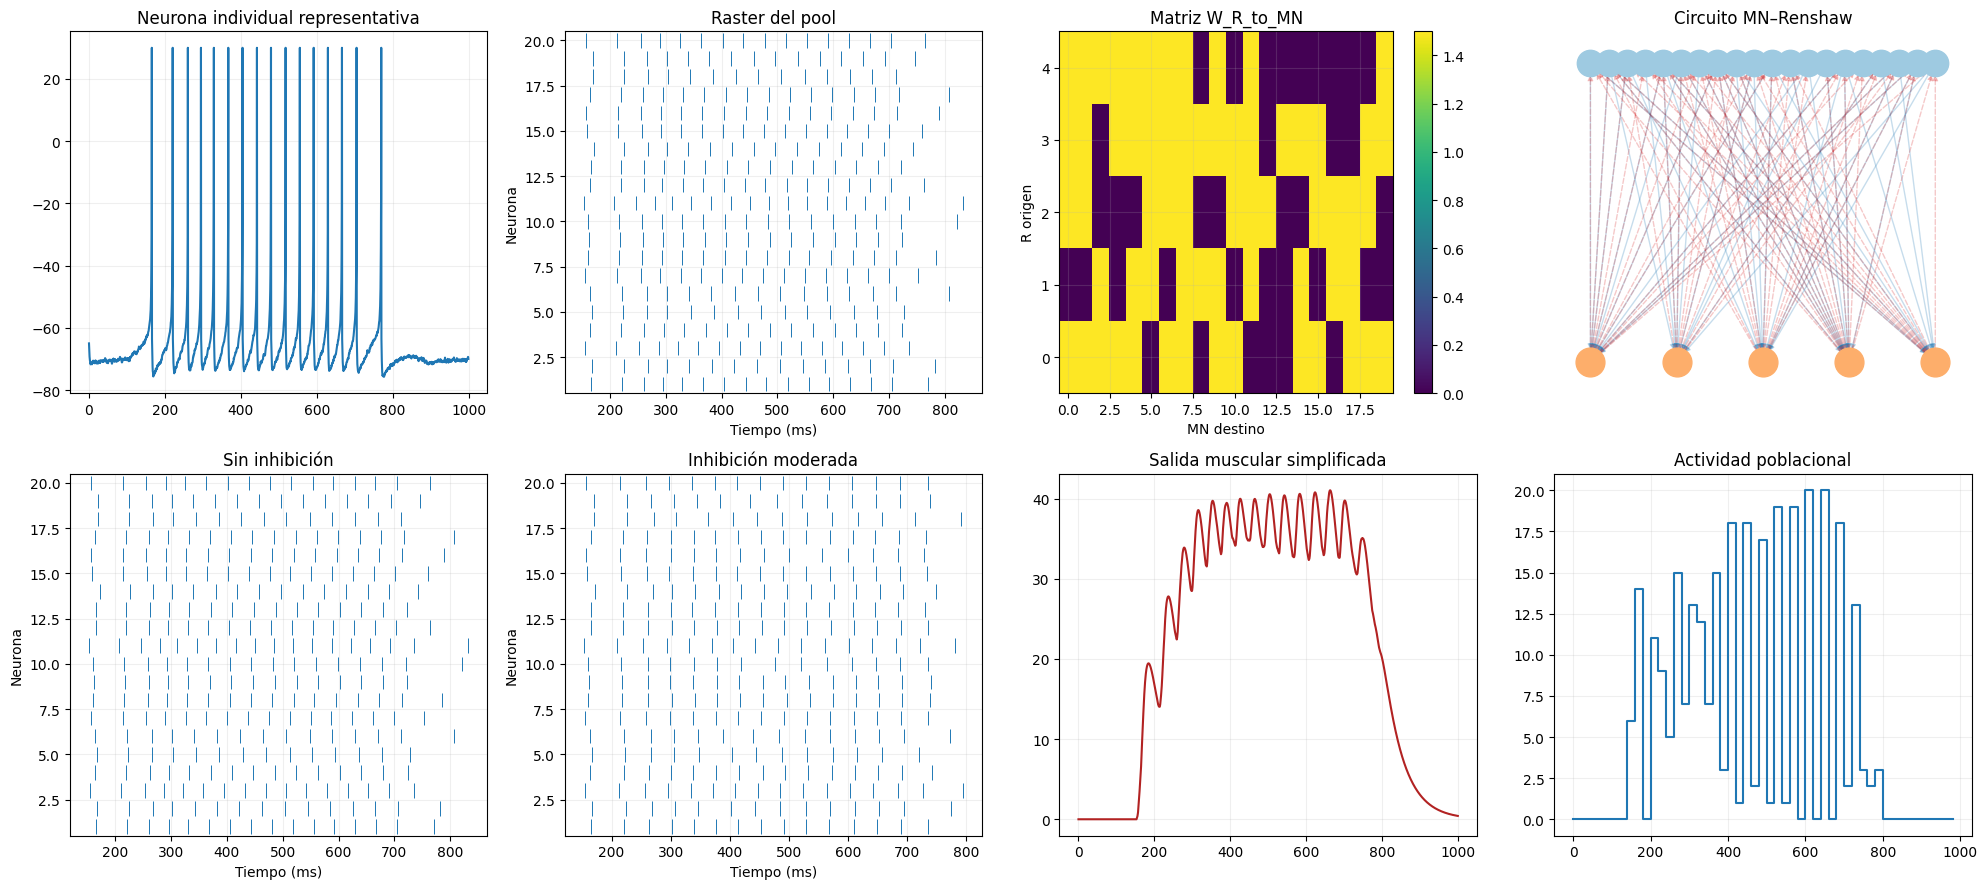

In [3]:
BASE = dict(n_motor=20, n_renshaw=5, amplitude=12., parameter_noise=.03, input_noise=.5,
            p_mn_to_r=.5, w_mn_to_r=1.5, p_r_to_mn=.6, synaptic_tau=10.,
            total_time=1000., dt=.5, seed=42, input_type="motor_plan")
control = simulate_renshaw_circuit(**BASE, w_r_to_mn=0., recurrent_inhibition=False)
moderate = simulate_renshaw_circuit(**BASE, w_r_to_mn=1.5, recurrent_inhibition=True)
force = spikes_to_force(moderate["spikes_MN"], moderate["time"])

summary_table = pd.DataFrame([
    {"escenario": "Sin inhibición", **neural_summary(control["spikes_MN"], control["time"], control["I_R_to_MN"])},
    {"escenario": "Moderada", **neural_summary(moderate["spikes_MN"], moderate["time"], moderate["I_R_to_MN"])},
]).set_index("escenario")
display(summary_table)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes[0,0].plot(control["time"], control["V_MN"][0]); axes[0,0].set_title("Neurona individual representativa")
plot_raster(spike_times_from_matrix(control["spikes_MN"], control["time"]), axes[0,1]); axes[0,1].set_title("Raster del pool")
im = axes[0,2].imshow(moderate["W_R_to_MN"], aspect="auto", origin="lower", cmap="viridis")
axes[0,2].set(title="Matriz W_R_to_MN", xlabel="MN destino", ylabel="R origen"); fig.colorbar(im, ax=axes[0,2])
plot_renshaw_circuit(moderate["W_MN_to_R"], moderate["W_R_to_MN"], axes[0,3], show_labels=False)
for ax, result, title in [(axes[1,0], control, "Sin inhibición"), (axes[1,1], moderate, "Inhibición moderada")]:
    plot_raster(spike_times_from_matrix(result["spikes_MN"], result["time"]), ax); ax.set_title(title)
axes[1,2].plot(moderate["time"], force, color="firebrick"); axes[1,2].set_title("Salida muscular simplificada")
bins, activity = population_activity(moderate["spikes_MN"], moderate["dt"], 20)
axes[1,3].step(bins, activity, where="post"); axes[1,3].set_title("Actividad poblacional")
for ax in axes.flat: ax.grid(alpha=.2)
fig.tight_layout(); plt.show()


## Lectura integrada de los resultados

El circuito implementado muestra que el feedback Renshaw puede modificar la salida del pool motor. La señal muscular hereda esos cambios porque se calcula directamente a partir de los spikes.

La conclusión más sólida es cualitativa y acotada:

> Dentro de este modelo, manteniendo constante la realización aleatoria, aumentar la magnitud inhibitoria reduce modestamente la actividad total y la fuerza media, aunque no todas las métricas temporales cambian de manera monotónica.

Para fortalecer esa afirmación se recomienda repetir el experimento con varias semillas, reportar dispersión y comprobar sensibilidad a `dt`, pesos, probabilidades y constante sináptica.

## Conclusiones

- El modelo de Izhikevich permite generar varios patrones de disparo con pocas variables y bajo costo computacional.
- El input controla el régimen de activación; el ruido y la heterogeneidad evitan que todo el pool responda de forma idéntica.
- La matriz `W` hace explícitas dirección, densidad y magnitud de las interacciones.
- En este circuito, el efecto observado de la inhibición recurrente debe leerse en la tabla y los rasters de la ejecución: no se asume que siempre estabilice o reduzca monótonamente la actividad.
- La fuerza simplificada integra temporalmente los spikes; conecta salida neuronal y una señal contráctil, pero no equivale a fuerza muscular experimental.

## Limitaciones

- Parámetros no calibrados específicamente con datos experimentales.
- Conexiones aleatorias e input motor artificial.
- Representación simplificada de motoneuronas y Renshaw con presets RS/FS.
- Modelo muscular lineal y no biomecánico.
- Sin feedback sensorial, músculo antagonista, retardos axonales, plasticidad ni fatiga.

## Trabajo futuro

- Calibrar parámetros y conectividad con bibliografía y datos.
- Agregar inhibición recíproca y pools agonista–antagonista.
- Incorporar huso neuromuscular y órgano tendinoso de Golgi.
- Implementar feedback sensorial, retardos y unidades motoras heterogéneas.
- Mejorar la visualización muscular y, recién después, conectarla con biomecánica.